In [ ]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [9]:
# Read the data
df = pd.read_csv('WildBlueberryPollinationSimulationData.csv', index_col=[0])

df.head()
print(df.columns)


Index(['clonesize', 'honeybee', 'bumbles', 'andrena', 'osmia',
       'MaxOfUpperTRange', 'MinOfUpperTRange', 'AverageOfUpperTRange',
       'MaxOfLowerTRange', 'MinOfLowerTRange', 'AverageOfLowerTRange',
       'RainingDays', 'AverageRainingDays', 'fruitset', 'fruitmass', 'seeds',
       'yield'],
      dtype='object')


In [ ]:
features = ["clonesize", "honeybee", "bumbles", "andrena", "osmia", "MaxOfUpperTRange","RainingDays"]
y = df.loc[:, ['yield']]

X = df.loc[:,features]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [15]:
model = XGBRegressor(eval_metric='rmsle')
from sklearn.model_selection import GridSearchCV

param_grid = {"max_depth":    [4, 5, 6],
              "n_estimators": [500, 600, 700],
              "learning_rate": [0.01, 0.015]}


search = GridSearchCV(model, param_grid, cv=5).fit(X_train, y_train)

print("The best hyperparameters are ",search.best_params_)



The best hyperparameters are  {'learning_rate': 0.015, 'max_depth': 4, 'n_estimators': 700}


In [16]:
regressor=XGBRegressor(learning_rate = search.best_params_["learning_rate"],
                           n_estimators  = search.best_params_["n_estimators"],
                           max_depth     = search.best_params_["max_depth"],
                           eval_metric='rmsle')

regressor.fit(X_train, y_train)

predictions = regressor.predict(X_test)


In [20]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

R2_sklearn = r2_score(y_test, predictions)
print(f"R2 score: {R2_sklearn}")
MSE = mean_squared_error(y_test, predictions)
print("The score is %.5f" % MSE )

R2 score: 0.9440745711326599
The score is 108698.25781


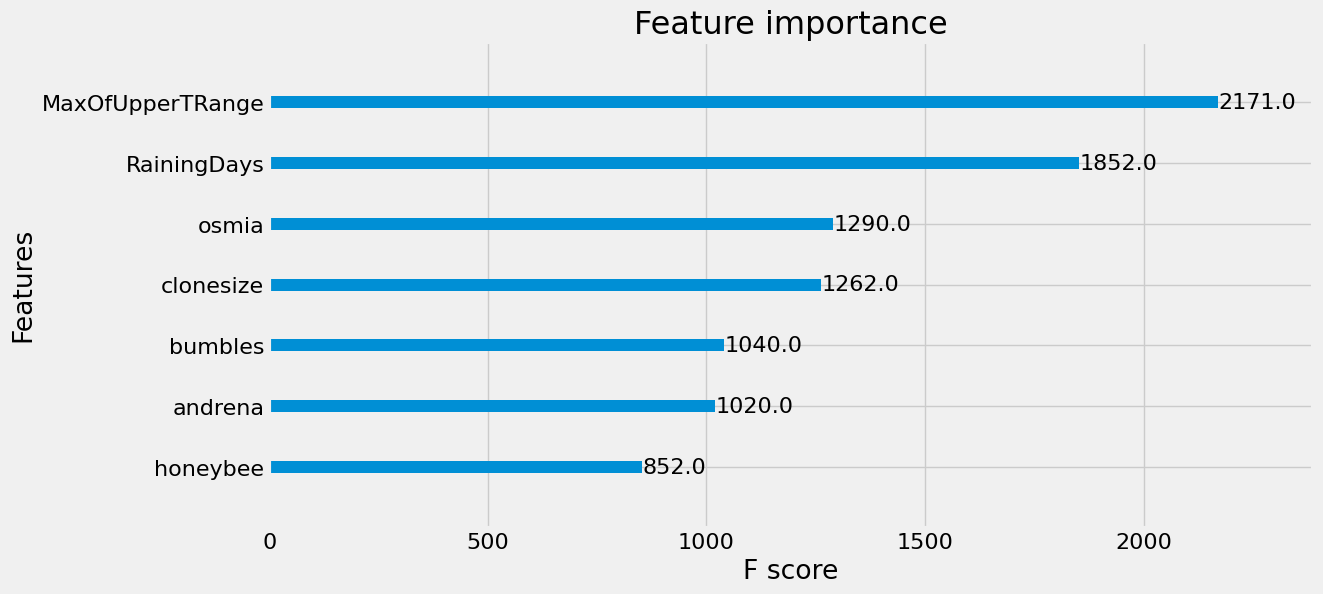

In [18]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams.update({'font.size': 16})

fig, ax = plt.subplots(figsize=(12,6))
plot_importance(regressor, max_num_features=8, ax=ax)
plt.show()